<Axes: >

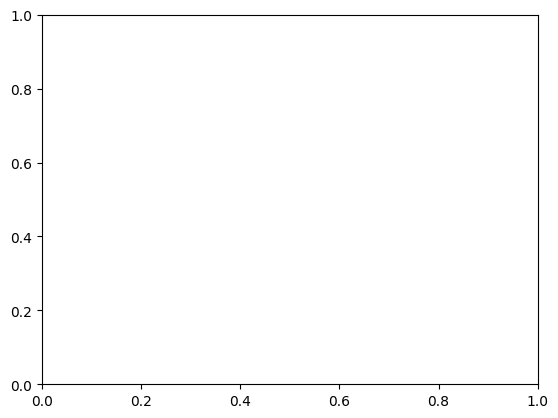

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.subplot()

In [1]:
from sys import path as syspath
from os import path as ospath

syspath.insert(1, r'D:\ARTM\topic-modelling-attention\src')
syspath

In [4]:
import jax.numpy as jnp
import numpy as np 

from sklearn.datasets import fetch_20newsgroups

import matplotlib.pyplot as plt
import seaborn as sns

from cartm.model import ContextTopicModel
from cartm.preprocessing import DatasetPreprocessor

This example will guide you through the basic interaction with the model.

## Data preprocessing

First, let's download a sample dataset and preprocess it with `DatasetPreprocessor`.

In [4]:
#data = fetch_20newsgroups(data_home='./data/', subset='all').data
#print(f'Total number of documents in corpus: {len(data)}')
#print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 18846
Total number of words in corpus: 5937230


In [6]:
with open('./data/test_data.txt') as f:
    data = f.readlines()
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 4
Total number of words in corpus: 34


In [7]:
preprocessor = DatasetPreprocessor()
tokenized_data, document_bounds = preprocessor.fit_transform(data)
print(f'Total number of document boundaries in preprocessed corpus: {len(document_bounds)}')
print(f'Total number of tokenized words in preprocessed corpus: {len(tokenized_data)}')

Total number of document boundaries in preprocessed corpus: 5
Total number of tokenized words in preprocessed corpus: 20


The `DatasetPreprocessor` class handles the filtering and tokenizing of the raw data. Its method `fit_transform` learns the vocabulary of the passed corpus of documents and returns tokenized words from corpus as the first return value, and document bounds as the second return value.

By default, `DatasetPreprocessor` removes stopwords, digits and special characters, therefore the total number of tokenized words is less than the number of words in raw corpus. Document boundaries are at the beginning and ending of the document, therefore the number of boundaries is [number_of_documents] + 1.

The returned values from `fit_transform` have jax.numpy.ndarray type, so you can work with them like a normal arrays.

In [8]:
print(f'Number of unique words in the preprocessed corpus: {jnp.max(tokenized_data)}')

Number of unique words in the preprocessed corpus: 18


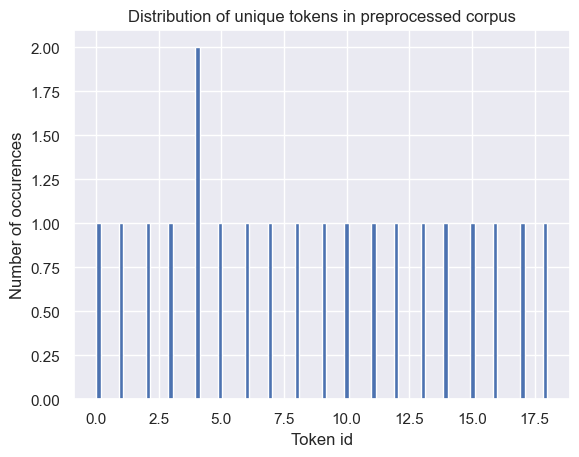

In [10]:
sns.set_theme()

plt.hist(tokenized_data, bins=100)

plt.xlabel('Token id')
plt.ylabel('Number of occurences')
plt.title('Distribution of unique tokens in preprocessed corpus')
#plt.yscale('log')
plt.show()

### Accessing vocabulary

You can also access mapping of words to tokens after fitting the preprocessor with data.

In [12]:
vocabulary = preprocessor.vocabulary

for i, (word, token) in enumerate(vocabulary.items()):
    print(f'{word}: {token}')
    if i == 10:
        break

reverse_vocab = {value: key for key, value in vocabulary.items()}
[reverse_vocab[t] for t in tokenized_data.tolist()]

lead: 0
time: 1
would: 2
sometim: 3
new: 4
begin: 5
day: 6
someth: 7
tri: 8
step: 9
best: 10


## Model training

Having the data preprocessed with `DatasetPreprocessor`, we can fit out model pretty straighforwardly.

Please note that calling `fit` method multiple times in one model will discard all results of the previous training.

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
from cartm.model import ContextTopicModel

topic_model = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    n_topics=20
)

topic_model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    verbose=2,
    seed=42,
)

start model
Iteration [1/1000], _phi update diff norm: 0.1585
Iteration [2/1000], _phi update diff norm: 0.0102
Iteration [3/1000], _phi update diff norm: 0.0156
Iteration [4/1000], _phi update diff norm: 0.0246
Iteration [5/1000], _phi update diff norm: 0.0347
Iteration [6/1000], _phi update diff norm: 0.0389
Iteration [7/1000], _phi update diff norm: 0.0379
Iteration [8/1000], _phi update diff norm: 0.0367
Iteration [9/1000], _phi update diff norm: 0.0387
Iteration [10/1000], _phi update diff norm: 0.0405
Iteration [11/1000], _phi update diff norm: 0.0358
Iteration [12/1000], _phi update diff norm: 0.0301
Iteration [13/1000], _phi update diff norm: 0.0280
Iteration [14/1000], _phi update diff norm: 0.0263
Iteration [15/1000], _phi update diff norm: 0.0243
Iteration [16/1000], _phi update diff norm: 0.0220
Iteration [17/1000], _phi update diff norm: 0.0199
Iteration [18/1000], _phi update diff norm: 0.0184
Iteration [19/1000], _phi update diff norm: 0.0173
Iteration [20/1000], _phi up

In [21]:
from cartm.experimental_model import ExperimentalContextTopicModel

topic_model = ExperimentalContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    n_topics=20
)

topic_model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    verbose=2,
    seed=42,
)

start experimantal_model
Iteration [1/1000], _phi update diff norm: 0.1585
Iteration [2/1000], _phi update diff norm: 0.0102
Iteration [3/1000], _phi update diff norm: 0.0156
Iteration [4/1000], _phi update diff norm: 0.0246
Iteration [5/1000], _phi update diff norm: 0.0347
Iteration [6/1000], _phi update diff norm: 0.0389
Iteration [7/1000], _phi update diff norm: 0.0379
Iteration [8/1000], _phi update diff norm: 0.0367
Iteration [9/1000], _phi update diff norm: 0.0387
Iteration [10/1000], _phi update diff norm: 0.0405
Iteration [11/1000], _phi update diff norm: 0.0358
Iteration [12/1000], _phi update diff norm: 0.0301
Iteration [13/1000], _phi update diff norm: 0.0280
Iteration [14/1000], _phi update diff norm: 0.0263
Iteration [15/1000], _phi update diff norm: 0.0243
Iteration [16/1000], _phi update diff norm: 0.0220
Iteration [17/1000], _phi update diff norm: 0.0199
Iteration [18/1000], _phi update diff norm: 0.0184
Iteration [19/1000], _phi update diff norm: 0.0173
Iteration [20/1

The model training stops because the update diff norm becomes too low. This means that the model has converged. You can modify the convergence threshold and max number of iterations.

In [17]:
topic_model_tol = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
)

topic_model_tol.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    tol=0.01,
    verbose=2,
    seed=42,
)

Iteration [1/1000], phi update diff norm: 0.1313
Iteration [2/1000], phi update diff norm: 0.0239
Iteration [3/1000], phi update diff norm: 0.0431
Iteration [4/1000], phi update diff norm: 0.0554
Iteration [5/1000], phi update diff norm: 0.0529
Iteration [6/1000], phi update diff norm: 0.0457
Iteration [7/1000], phi update diff norm: 0.0460
Iteration [8/1000], phi update diff norm: 0.0522
Iteration [9/1000], phi update diff norm: 0.0621
Iteration [10/1000], phi update diff norm: 0.0727
Iteration [11/1000], phi update diff norm: 0.0779
Iteration [12/1000], phi update diff norm: 0.0699
Iteration [13/1000], phi update diff norm: 0.0509
Iteration [14/1000], phi update diff norm: 0.0337
Iteration [15/1000], phi update diff norm: 0.0236
Iteration [16/1000], phi update diff norm: 0.0180
Iteration [17/1000], phi update diff norm: 0.0146
Iteration [18/1000], phi update diff norm: 0.0120
Iteration [19/1000], phi update diff norm: 0.0100


In [18]:
topic_model_iter = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
)

topic_model_iter.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    max_iter=10,
    verbose=2,
    seed=42,
)

Iteration [1/10], phi update diff norm: 0.1313
Iteration [2/10], phi update diff norm: 0.0239
Iteration [3/10], phi update diff norm: 0.0431
Iteration [4/10], phi update diff norm: 0.0554
Iteration [5/10], phi update diff norm: 0.0529
Iteration [6/10], phi update diff norm: 0.0457
Iteration [7/10], phi update diff norm: 0.0460
Iteration [8/10], phi update diff norm: 0.0522
Iteration [9/10], phi update diff norm: 0.0621
Iteration [10/10], phi update diff norm: 0.0727


You can also modify number of topics and other parameters of the model. Refer to the `fit` funciton docs for more info about model training.

## Analysis

After the model is fitted, you can access its parameters and analyse them.

In [9]:
phi_wt = topic_model.phi  # p(w|t)
n_t = topic_model.n_t  # denormalized distribution of topics
print(f'phi matrix type: {type(phi_wt)}, shape: {phi_wt.shape}')
print(f'n_t array type: {type(n_t)}, shape: {n_t.shape}')

phi matrix type: <class 'jaxlib._jax.ArrayImpl'>, shape: (90682, 20)
n_t array type: <class 'jaxlib._jax.ArrayImpl'>, shape: (20,)


### Plot a histogram of a distribution of topics in corpus:

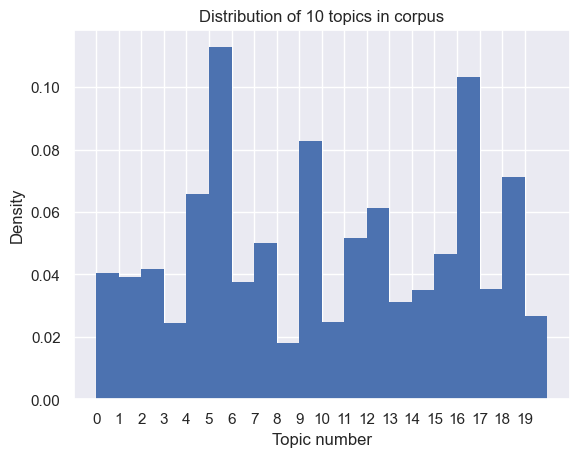

In [10]:
plt.stairs(n_t / n_t.sum(), range(len(n_t) + 1), fill=True)

plt.xticks(range(len(n_t)))
plt.xlabel('Topic number')
plt.ylabel('Density')
plt.title('Distribution of 10 topics in corpus')
plt.show()

### Print top-10 words from each topic:

In [12]:
# find top-10 words with the biggest probability p(w|t) for each topic t
topk = jnp.argsort(phi_wt, axis=0, descending=True)[:20, :].T

# create mapping token -> word from existing mapping word -> token (vocabulary)
reverse_vocab = {value: key for key, value in vocabulary.items()}

for topic_idx, t in enumerate(topk):
    print(f'Topic {topic_idx + 1}:', '\t'.join([reverse_vocab[int(idx)] for idx in t]))
    print()

Topic 1: studi	effect	caus	use	medic	drug	increas	rate	high	health	food	diseas	patient	report	level	test	care	result	low	larg

Topic 2: max	armenian	israel	war	jew	isra	muslim	kill	arab	peopl	turkish	attack	countri	arm	jewish	armenia	american	turk	govern	turkey

Topic 3: game	team	play	player	win	hockey	fan	season	basebal	score	hit	leagu	goal	red	pitch	first	best	nhl	playoff	seri

Topic 4: new	price	sale	york	pay	page	book	mil	sell	compani	ship	tax	number	includ	publish	cost	navi	insur	volum	print

Topic 5: know	like	get	would	good	anyon	look	want	work	think	say	someth	one	realli	thing	els	someon	well	let	could

Topic 6: would	peopl	one	make	think	way	even	thing	could	may	much	seem	point	say	right	mani	see	differ	might	reason

Topic 7: com	post	host	nntp	line	subject	netcom	articl	write	sun	att	repli	mit	world	organ	mark	appl	stratu	bob	frank

Topic 8: edu	articl	apr	write	subject	uiuc	repli	news	gmt	cwru	cso	michael	rutger	berkeley	columbia	pitt	caltech	stanford	may	utexa

Topic 9: co

In [ ]:
[reverse_vocab[i] for i in reverse_vocab if len(reverse_vocab[i]) == 2]

In [6]:
voc = preprocessor.vocabulary

In [22]:
[1.0, ] + 

[1.0]